## Seaborn

In [26]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## 1 Установливаем соединение с базой данных.

In [27]:
conn = sqlite3.connect('/Users/cleganeb/Desktop/DSB9_Pandas_SQL_Data_Visual.ID_1577652-1/src/data/checking-logs.sqlite')

## 2 Достанем и подготовим данные из таблицы checker (только пользователи).

In [28]:
query = """
SELECT 
    uid,
    timestamp,
    numTrials
FROM checker
WHERE uid LIKE 'user_%' AND labname = 'project1' AND status = 'ready'
"""
checker = pd.io.sql.read_sql(query, conn)
checker["timestamp"] = pd.to_datetime(checker["timestamp"])
display(checker)

,uid,timestamp,numTrials
0,user_4,2020-04-17 05:19:02.744528,1
1,user_4,2020-04-17 05:22:45.549397,2
2,user_4,2020-04-17 05:34:24.422370,3
3,user_4,2020-04-17 05:43:27.773992,4
4,user_4,2020-04-17 05:46:32.275104,5
...,...,...,...
946,user_19,2020-05-15 10:22:39.698523,26
947,user_19,2020-05-15 10:22:46.248162,27
948,user_19,2020-05-15 10:23:18.043212,28
949,user_28,2020-05-15 10:38:14.430013,27


## 3 Построим график.

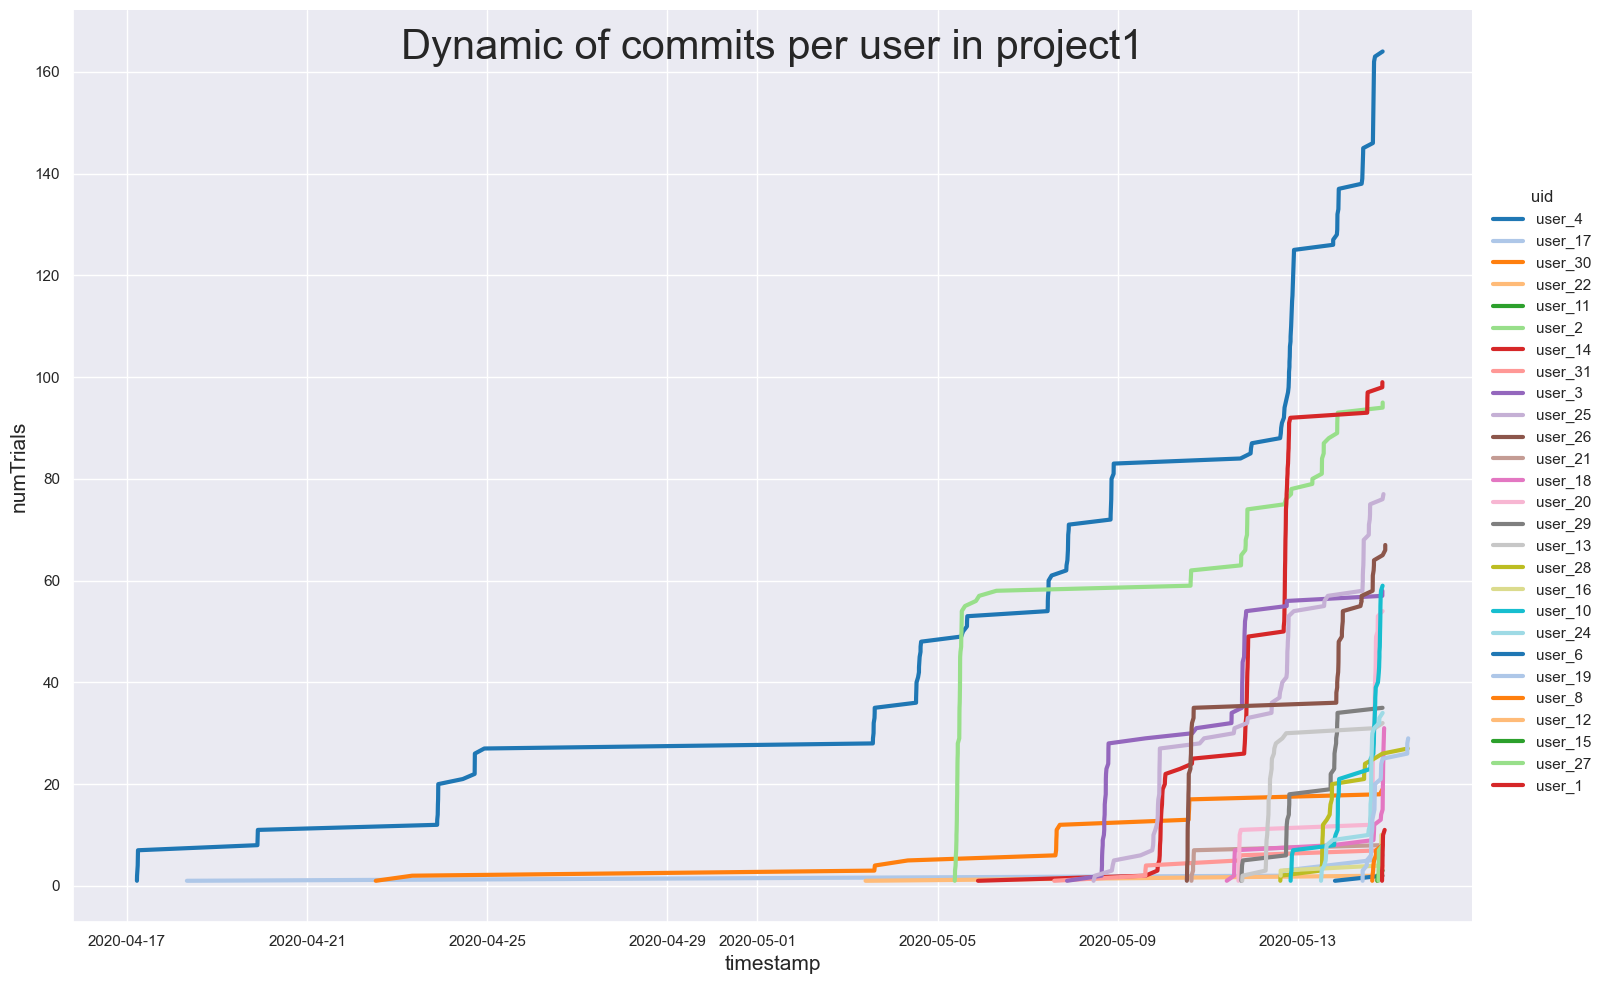

In [29]:
sns.set_theme(style="darkgrid")

graf = sns.relplot(
    data=checker,
    x="timestamp",
    y="numTrials",
    hue="uid",
    kind="line",
    linewidth=3,
    height=10,
    aspect=1.5,
    palette="tab20"
)
ax = graf.ax

title = "Dynamic of commits per user in project1"
ax.text(
    0.5, 0.98, title,
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=30
)

ax.set_xlabel("timestamp", fontsize=15)
ax.set_ylabel("numTrials", fontsize=15)

plt.tight_layout(rect=[0, 0, 0.93, 1]) 
plt.show()

## 4 Какой пользователь почти все время лидировал по количеству коммитов?
## Какой пользователь был лидером лишь в течение короткого периода времени?

In [30]:
print(f"Постоянный лидер: user_4")
print(f"Временный лидер: user_2")

Постоянный лидер: user_4
Временный лидер: user_2


## 5 Закроем соединение с базой данных.

In [31]:
conn.close()